In [ ]:
install.packages("devtools")
install.packages("remotes")
install.packages("ggplot2")
devtools::install_github("coatless/ucidata")

library(ucidata)
data(wine)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Skipping install of 'ucidata' from a github remote, the SHA1 (0ce85595) has not changed since last install.
  Use `force = TRUE` to force installation



Data Structure

In [ ]:
str(wine)
summary(wine)

'data.frame':	6497 obs. of  13 variables:
 $ fixed_acidity       : num  7.4 7.8 7.8 11.2 7.4 7.4 7.9 7.3 7.8 7.5 ...
 $ volatile_acidity    : num  0.7 0.88 0.76 0.28 0.7 0.66 0.6 0.65 0.58 0.5 ...
 $ citric_acid         : num  0 0 0.04 0.56 0 0 0.06 0 0.02 0.36 ...
 $ residual_sugar      : num  1.9 2.6 2.3 1.9 1.9 1.8 1.6 1.2 2 6.1 ...
 $ chlorides           : num  0.076 0.098 0.092 0.075 0.076 0.075 0.069 0.065 0.073 0.071 ...
 $ free_sulfur_dioxide : num  11 25 15 17 11 13 15 15 9 17 ...
 $ total_sulfur_dioxide: num  34 67 54 60 34 40 59 21 18 102 ...
 $ density             : num  0.998 0.997 0.997 0.998 0.998 ...
 $ pH                  : num  3.51 3.2 3.26 3.16 3.51 3.51 3.3 3.39 3.36 3.35 ...
 $ sulphates           : num  0.56 0.68 0.65 0.58 0.56 0.56 0.46 0.47 0.57 0.8 ...
 $ alcohol             : num  9.4 9.8 9.8 9.8 9.4 9.4 9.4 10 9.5 10.5 ...
 $ quality             : int  5 5 5 6 5 5 5 7 7 5 ...
 $ color               : Factor w/ 2 levels "Red","White": 1 1 1 1 1 1 1 1 1 1 ...


 fixed_acidity    volatile_acidity  citric_acid     residual_sugar  
 Min.   : 3.800   Min.   :0.0800   Min.   :0.0000   Min.   : 0.600  
 1st Qu.: 6.400   1st Qu.:0.2300   1st Qu.:0.2500   1st Qu.: 1.800  
 Median : 7.000   Median :0.2900   Median :0.3100   Median : 3.000  
 Mean   : 7.215   Mean   :0.3397   Mean   :0.3186   Mean   : 5.443  
 3rd Qu.: 7.700   3rd Qu.:0.4000   3rd Qu.:0.3900   3rd Qu.: 8.100  
 Max.   :15.900   Max.   :1.5800   Max.   :1.6600   Max.   :65.800  
   chlorides       free_sulfur_dioxide total_sulfur_dioxide    density      
 Min.   :0.00900   Min.   :  1.00      Min.   :  6.0        Min.   :0.9871  
 1st Qu.:0.03800   1st Qu.: 17.00      1st Qu.: 77.0        1st Qu.:0.9923  
 Median :0.04700   Median : 29.00      Median :118.0        Median :0.9949  
 Mean   :0.05603   Mean   : 30.53      Mean   :115.7        Mean   :0.9947  
 3rd Qu.:0.06500   3rd Qu.: 41.00      3rd Qu.:156.0        3rd Qu.:0.9970  
 Max.   :0.61100   Max.   :289.00      Max.   :440.0   

1. There are a couple of outliers in density, remove them.

In [ ]:
Q1 <- quantile(wine$density, 0.25)
Q3 <- quantile(wine$density, 0.75)
IQR_val <- IQR(wine$density)

lower_bound <- Q1 - 1.5 * IQR_val
upper_bound <- Q3 + 1.5 * IQR_val

In [ ]:
wine_clean <- wine[wine$density >= lower_bound & wine$density <= upper_bound, ]

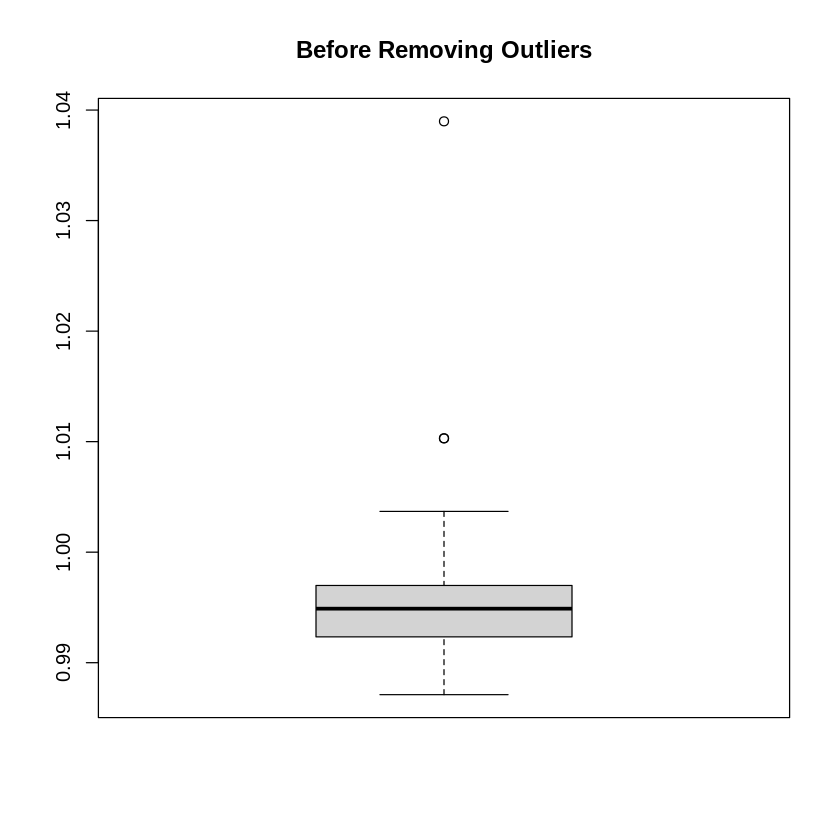

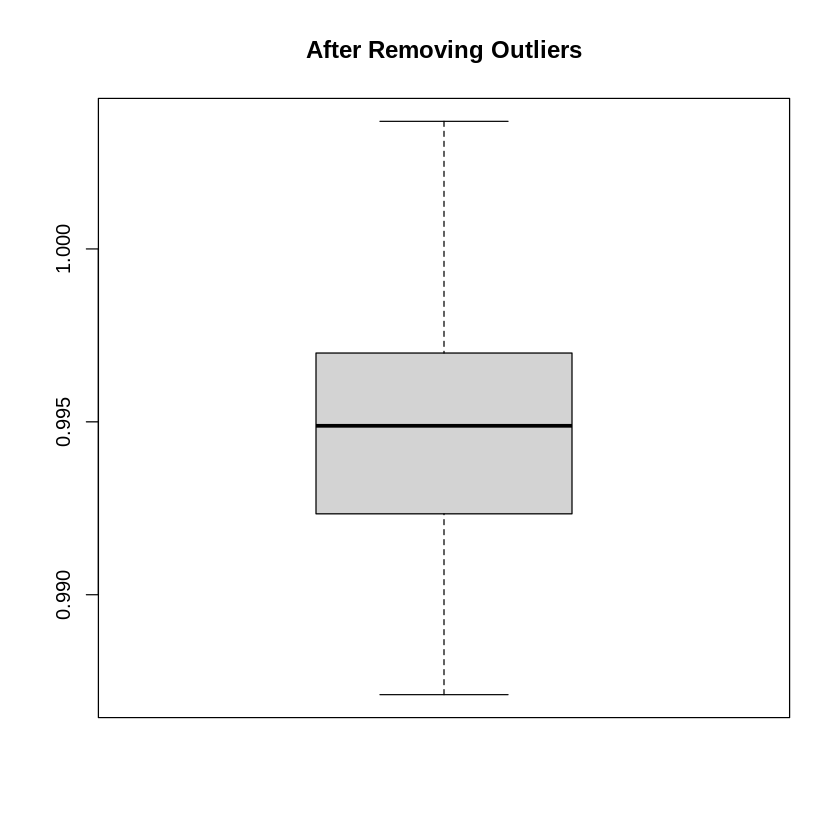

In [ ]:
boxplot(wine$density, main = "Before Removing Outliers")

boxplot(wine_clean$density, main = "After Removing Outliers")

  2. Make a scatterplot of wine type as a function of total sulfur dioxide. Add a loess smoother and a logistic regression smoother. Comment on similarities or differences.

 * (Note: To do this, you will need to change wine type from white/red to 0/1.)

In [ ]:
wine_clean$color_binary <- ifelse(wine_clean$color == "white", 1, 0)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“glm.fit: algorithm did not converge”


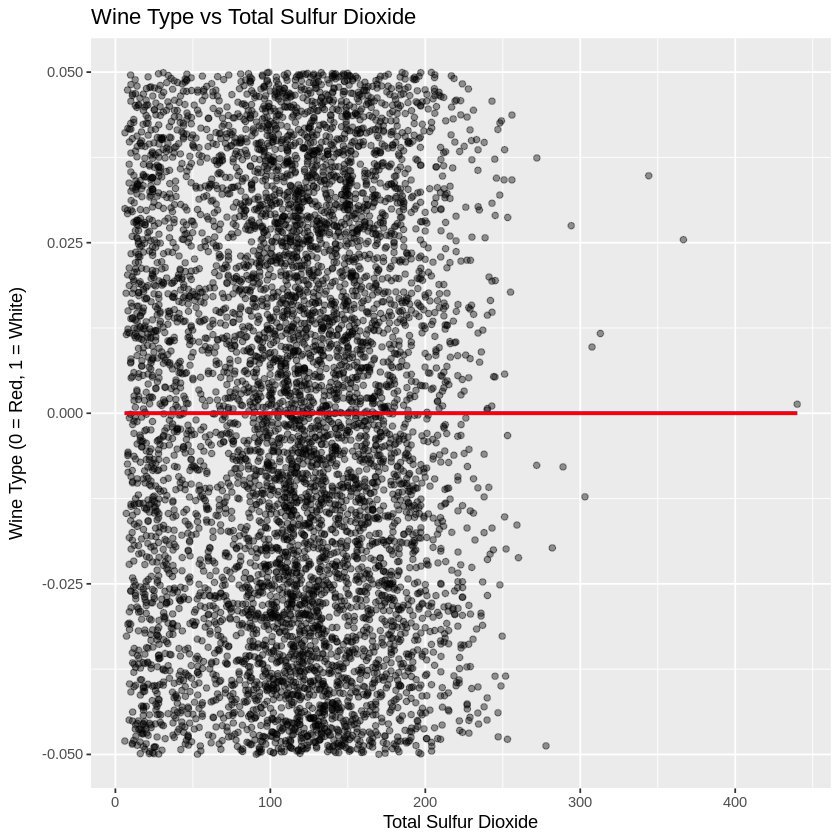

In [ ]:
ggplot(wine_clean, aes(x = total_sulfur_dioxide, y = color_binary)) +
  geom_jitter(height = 0.05, alpha = 0.4) +

  geom_smooth(method = "loess", color = "blue", se = FALSE) +

  geom_smooth(method = "glm",
              method.args = list(family = "binomial"),
              color = "red", se = FALSE) +

  labs(title = "Wine Type vs Total Sulfur Dioxide",
       x = "Total Sulfur Dioxide",
       y = "Wine Type (0 = Red, 1 = White)")

3. Make a scatterplot of wine type as a function of density. Add a loess smoother and a logistic regression smoother. Comment on similarities or differences.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“glm.fit: algorithm did not converge”


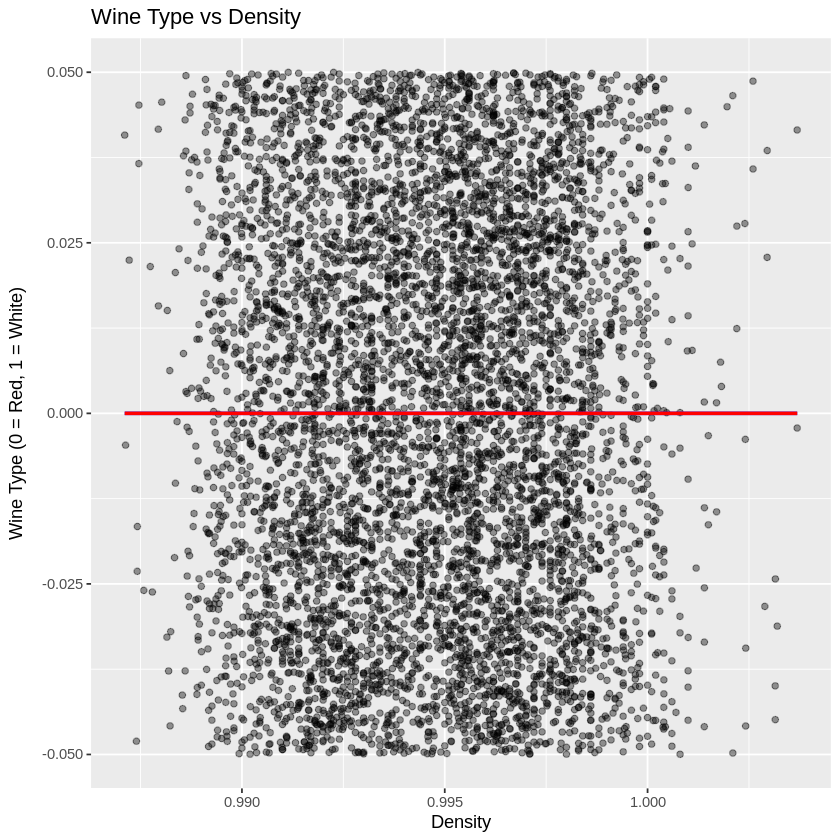

In [ ]:
ggplot(wine_clean, aes(x = density, y = color_binary)) +
  geom_jitter(height = 0.05, alpha = 0.4) +

  geom_smooth(method = "loess", color = "blue", se = FALSE) +

  geom_smooth(method = "glm",
              method.args = list(family = "binomial"),
              color = "red", se = FALSE) +

  labs(title = "Wine Type vs Density",
       x = "Density",
       y = "Wine Type (0 = Red, 1 = White)")

4. Fit two logistic regression models: one with no interaction between density and total sulfur dioxide and one with an interaction between density and total sulfur dioxide. Make two coplots for each model showing the fits. For each model, you should have one coplot of wine type as a function of density conditioned on total sulfur dioxide, and one with wine type as a function of total sulfur dioxide conditioned on density.

In [ ]:
model_no_int <- glm(color_binary ~ density + total_sulfur_dioxide,
                    data = wine_clean, family = "binomial")

model_int <- glm(color_binary ~ density * total_sulfur_dioxide,
                 data = wine_clean, family = "binomial")

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”


In [ ]:
wine_clean$pred_no_int <- predict(model_no_int, type = "response")
wine_clean$pred_int <- predict(model_int, type = "response")

In [ ]:
wine_clean$density_bins <- cut_number(wine_clean$density, n = 4)
wine_clean$tsd_bins <- cut_number(wine_clean$total_sulfur_dioxide, n = 4)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


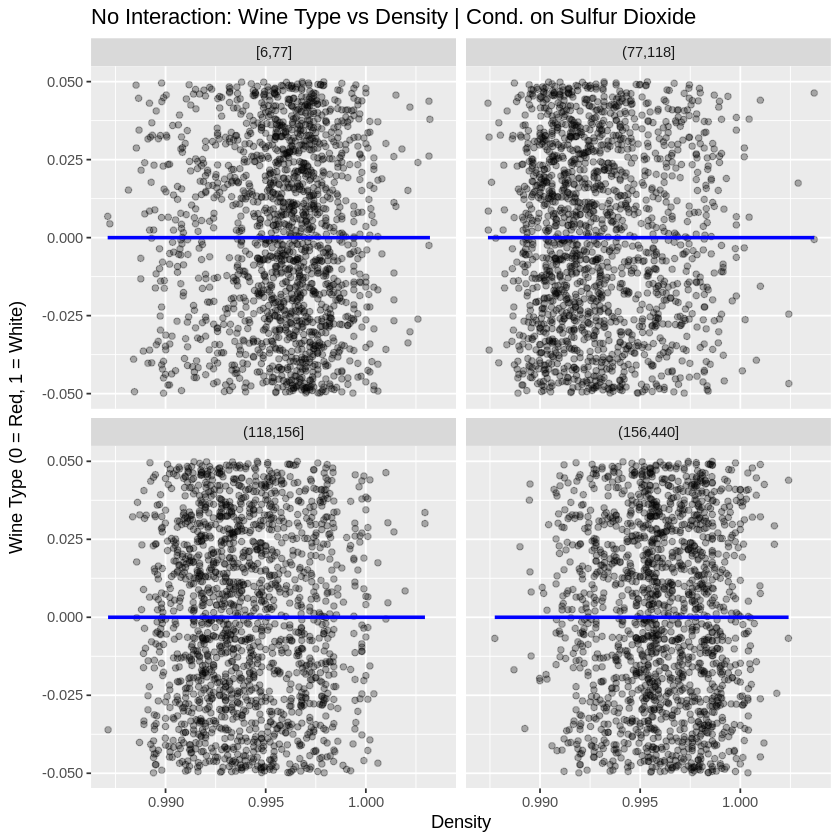

In [ ]:
ggplot(wine_clean[order(wine_clean$density), ], aes(x = density, y = color_binary)) +
  geom_jitter(height = 0.05, alpha = 0.3) +
  geom_line(aes(y = pred_no_int), color = "blue", size = 1) +
  facet_wrap(~ tsd_bins) +
  labs(title = "No Interaction: Wine Type vs Density | Cond. on Sulfur Dioxide",
       x = "Density", y = "Wine Type (0 = Red, 1 = White)")

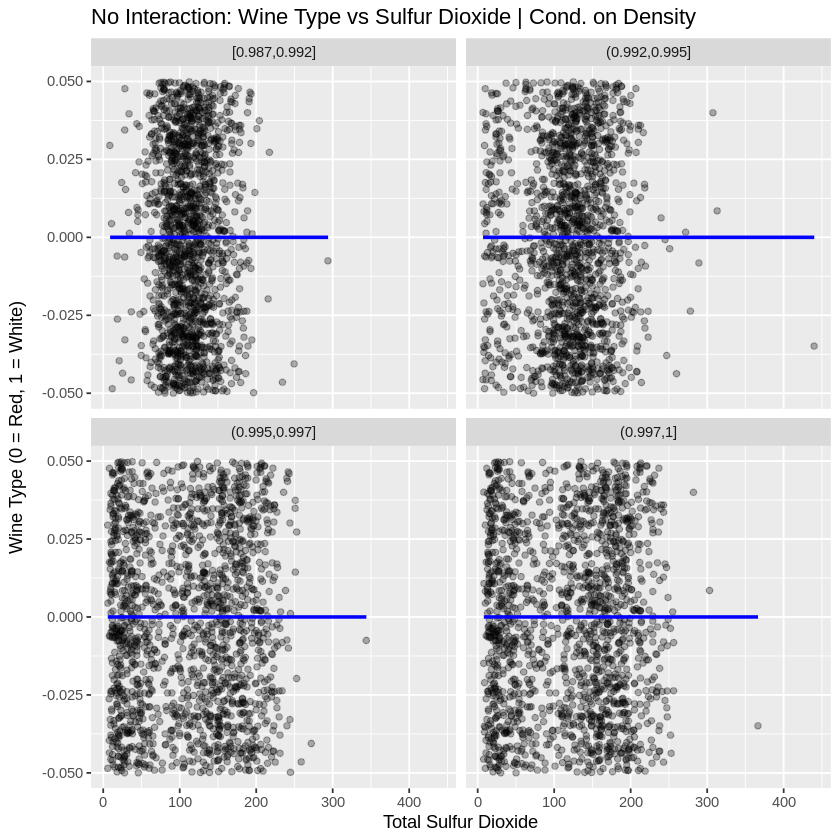

In [ ]:
ggplot(wine_clean[order(wine_clean$total_sulfur_dioxide), ], aes(x = total_sulfur_dioxide, y = color_binary)) +
  geom_jitter(height = 0.05, alpha = 0.3) +
  geom_line(aes(y = pred_no_int), color = "blue", size = 1) +
  facet_wrap(~ density_bins) +
  labs(title = "No Interaction: Wine Type vs Sulfur Dioxide | Cond. on Density",
       x = "Total Sulfur Dioxide", y = "Wine Type (0 = Red, 1 = White)")

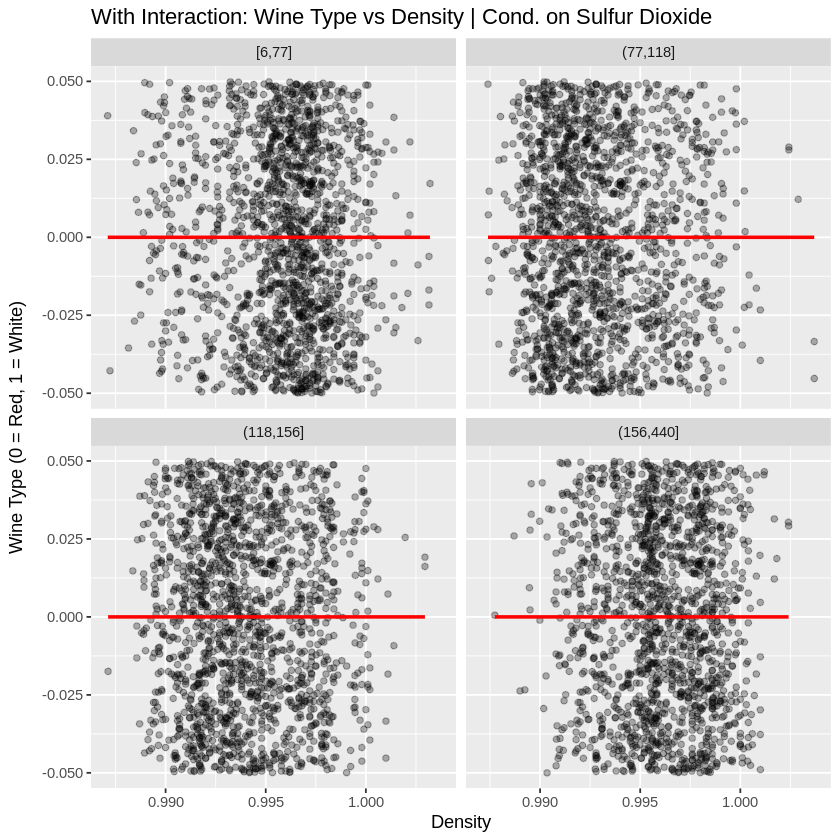

In [ ]:
ggplot(wine_clean[order(wine_clean$density), ], aes(x = density, y = color_binary)) +
  geom_jitter(height = 0.05, alpha = 0.3) +
  geom_line(aes(y = pred_int), color = "red", size = 1) +
  facet_wrap(~ tsd_bins) +
  labs(title = "With Interaction: Wine Type vs Density | Cond. on Sulfur Dioxide",
       x = "Density", y = "Wine Type (0 = Red, 1 = White)")

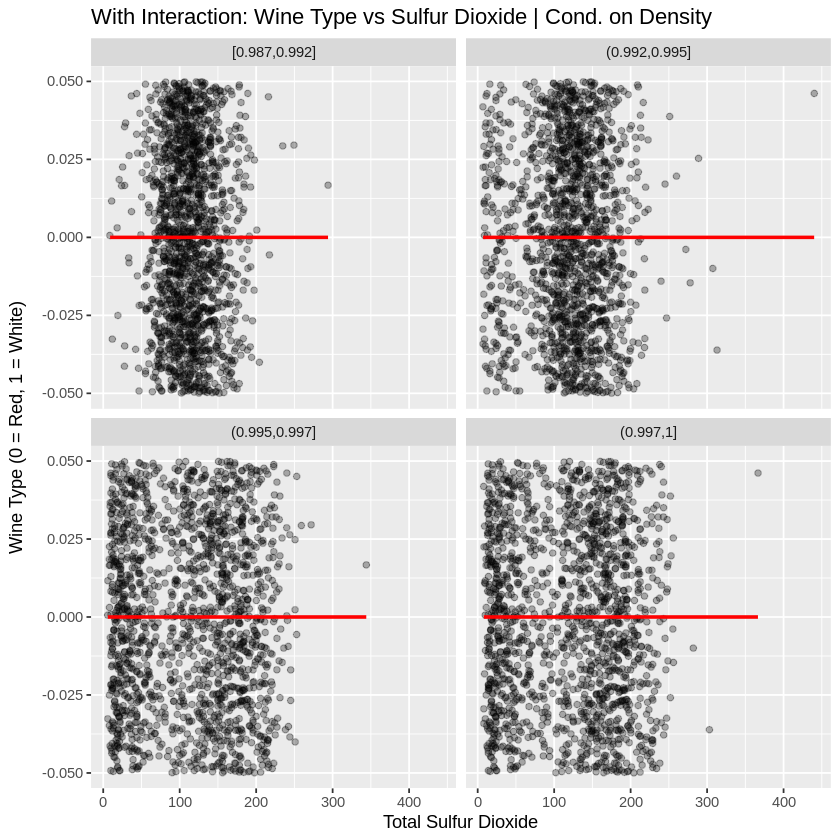

In [ ]:
ggplot(wine_clean[order(wine_clean$total_sulfur_dioxide), ], aes(x = total_sulfur_dioxide, y = color_binary)) +
  geom_jitter(height = 0.05, alpha = 0.3) +
  geom_line(aes(y = pred_int), color = "red", size = 1) +
  facet_wrap(~ density_bins) +
  labs(title = "With Interaction: Wine Type vs Sulfur Dioxide | Cond. on Density",
       x = "Total Sulfur Dioxide", y = "Wine Type (0 = Red, 1 = White)")

5. Comment briefly on what these plots tell you about the relationships among the three variables.

Looking at the data points, white wines tend to have lower densities while red wines have higher densities. A high density would have a lower sulfur dioxide and vice versa. In the "No Interaction" Models plots (Blue Lines), the shape and slope of the probability curve look practically identical across all four panels. The model forces the effect of density on wine color to be exactly the same, regardless of how much sulfur dioxide is in the wine (the curve just shifts a little bit left or right). In the "Interaction" Models  plots (Red Lines), the relationship becomes dynamic. The slope and steepness of the fitted curve actually change depending on the panel which tells that the effect density has on the probability of white wine depends heavily on the level of sulfur dioxide present (vice versa).